# Lesson 1 — Tensors & Autograd: Linear Regression by Hand

Visualizing the by-hand linear regression from `autograd.py`: the data, the fit as it trains, and the loss curve.

In [1]:
import matplotlib.pyplot as plt
import torch

## 1. Synthetic data

Same setup as the script — a true `w`/`b` plus noise.

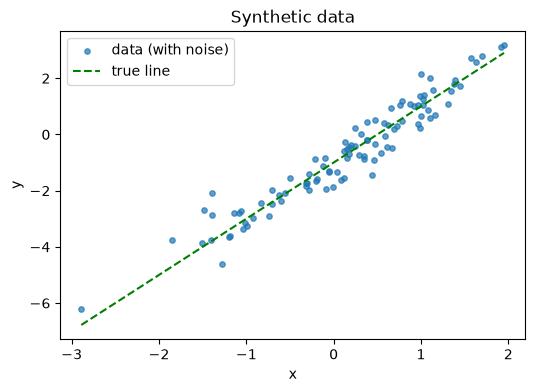

In [2]:
torch.manual_seed(0)

w_true = 2.0
b_true = -1.0

noise = torch.randn(100) * 0.5
x = torch.randn(100)
y = w_true * x + b_true + noise

plt.figure(figsize=(6, 4))
plt.scatter(x, y, s=15, alpha=0.7, label="data (with noise)")
xs = torch.linspace(x.min(), x.max(), 2)
plt.plot(xs, w_true * xs + b_true, color="green", linestyle="--", label="true line")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Synthetic data")
plt.show()

## 2. Learnable parameters

Initialized away from the true values so there's something to learn.

In [3]:
w = (torch.rand(1) * 10 - 5).requires_grad_()
b = (torch.rand(1) * 10 - 5).requires_grad_()
print(f"initial: w={w.item():.3f}, b={b.item():.3f}")

initial: w=0.624, b=4.478


## 3. Training loop

Same as the script, but stashing the loss and the line's snapshot every so often so we can plot how the fit evolves.

In [4]:
learning_rate = 0.1
epochs = 200

losses = []
snapshots = []  # (epoch, w, b) every N epochs, for the animated-fit plot

epoch = -1
try:
    for epoch in range(epochs):
        y_pred = w * x + b
        mse = ((y_pred - y) ** 2).mean()

        mse.backward()

        w.grad.zero_()
        b.grad.zero_()

        with torch.no_grad():
            w -= learning_rate * w.grad
            b -= learning_rate * b.grad

        losses.append(mse.item())

        if epoch % 20 == 0 or epoch == epochs - 1:
            snapshots.append((epoch, w.item(), b.item()))
            print(f"epoch {epoch:3d}  mse={mse.item():.4f}  w={w.item():.3f}  b={b.item():.3f}")
except:
    print(f"last epoch {epoch:3d}")
    raise

print(f"\nlearned: w={w.item():.3f} (true {w_true}), b={b.item():.3f} (true {b_true})")

epoch   0  mse=29.2251  w=0.624  b=4.478
epoch  20  mse=29.2251  w=0.624  b=4.478
epoch  40  mse=29.2251  w=0.624  b=4.478
epoch  60  mse=29.2251  w=0.624  b=4.478
epoch  80  mse=29.2251  w=0.624  b=4.478
epoch 100  mse=29.2251  w=0.624  b=4.478
epoch 120  mse=29.2251  w=0.624  b=4.478
epoch 140  mse=29.2251  w=0.624  b=4.478
epoch 160  mse=29.2251  w=0.624  b=4.478
epoch 180  mse=29.2251  w=0.624  b=4.478
epoch 199  mse=29.2251  w=0.624  b=4.478

learned: w=0.624 (true 2.0), b=4.478 (true -1.0)


## 4. Loss curve

Should drop sharply then flatten out as it converges.

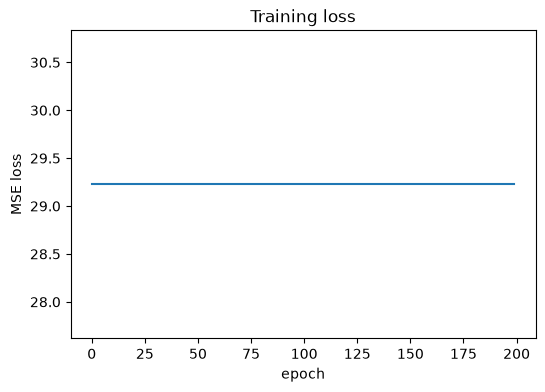

In [5]:
plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.title("Training loss")
plt.show()

## 5. Fit over time

Data points plus the learned line at each snapshot, so you can watch it converge onto the true line.

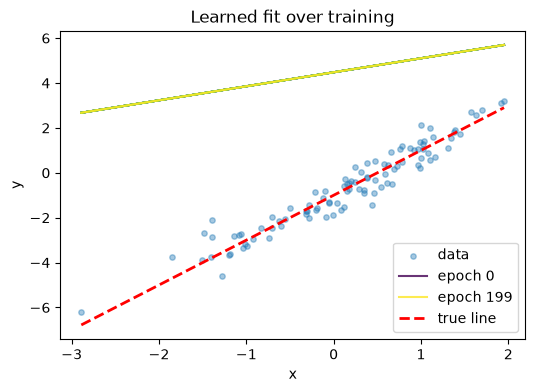

In [6]:
plt.figure(figsize=(6, 4))
plt.scatter(x, y, s=15, alpha=0.4, label="data")

xs = torch.linspace(x.min(), x.max(), 2)
cmap = plt.cm.viridis
for i, (epoch, w_snap, b_snap) in enumerate(snapshots):
    color = cmap(i / max(len(snapshots) - 1, 1))
    plt.plot(
        xs,
        w_snap * xs + b_snap,
        color=color,
        alpha=0.8,
        label=f"epoch {epoch}" if i in (0, len(snapshots) - 1) else None,
    )

plt.plot(xs, w_true * xs + b_true, color="red", linestyle="--", linewidth=2, label="true line")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Learned fit over training")
plt.show()